In [1]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import numpy              as np
import pandas             as pd
import warnings
warnings.filterwarnings('ignore')

from collections           import Counter
from Algorithm.Dbscan       import DBSCAN
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D, data_pca

Tiền xử lý dữ liệu

In [2]:
## Chuẩn bị dữ liệu
data = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
print(data.shape)
print(data.head())

(8636, 2)
       PCA1      PCA2
0 -0.230727 -2.937858
1 -3.519006  0.990269
2  1.404060  1.235079
3 -1.161154 -1.477582
4  1.125630  0.364839


In [3]:
## Quan sát sơ bộ dữ liệu
print('Shape:', data.shape)
print('Dtypes:')
print(data.dtypes)

Shape: (8636, 2)
Dtypes:
PCA1    float64
PCA2    float64
dtype: object


In [5]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(data, eps=0.2, min_samples=10)
(ticks, result) = timedcall(model.fit)
print(f"Thời gian chạy: {ticks:.4f} giây")

KeyboardInterrupt: 

In [7]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model, '../customer_clustering/Output/DBSCAN.mdl')

['../customer_clustering/Output/DBSCAN.mdl']

In [8]:
## Khai thác mô hình đã được xây dựng
loaded_model = jlb.load('../customer_clustering/Output/DBSCAN.mdl')

In [9]:
## Kết quả gom cụm khách hàng
data['cluster'] = loaded_model.get_labels()

n_clusters = loaded_model.n_clusters_
n_noise    = len(loaded_model.get_noise_points())

print(data.head(5))
print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('Kích thước các clusters (bao gồm noise = -1):', Counter(loaded_model.get_labels()))

       PCA1      PCA2  cluster
0 -0.230727 -2.937858        0
1 -3.519006  0.990269        0
2  1.404060  1.235079        0
3 -1.161154 -1.477582        0
4  1.125630  0.364839        0

Số clusters tìm được  : 17
Số điểm nhiễu (noise): 644
Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(0): 7750, np.int64(-1): 644, np.int64(4): 29, np.int64(1): 27, np.int64(6): 23, np.int64(5): 21, np.int64(13): 19, np.int64(2): 18, np.int64(7): 14, np.int64(3): 12, np.int64(14): 11, np.int64(10): 11, np.int64(9): 11, np.int64(15): 11, np.int64(11): 9, np.int64(12): 9, np.int64(16): 9, np.int64(8): 8})


Biểu diễn trực quan

In [10]:
## Hiển thị dữ liệu sau gom cụm
print(data.head())

       PCA1      PCA2  cluster
0 -0.230727 -2.937858        0
1 -3.519006  0.990269        0
2  1.404060  1.235079        0
3 -1.161154 -1.477582        0
4  1.125630  0.364839        0


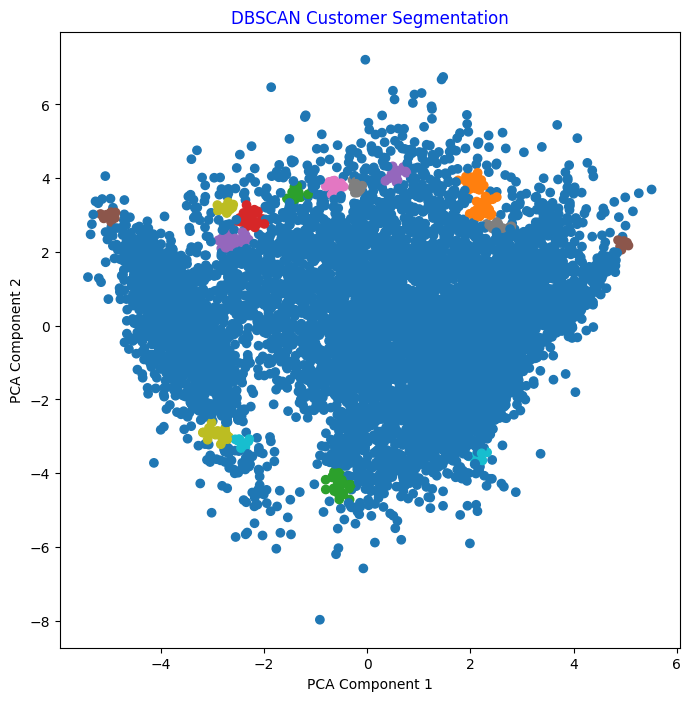

In [11]:
## Biểu diễn trực quan
plt.figure(figsize=(8, 8))
plt.scatter(
    data['PCA1'],
    data['PCA2'],
    c=data['cluster'],
    cmap='tab10'
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Customer Segmentation', color='blue')
plt.show()